# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [101]:
STUDENT_NAME = "Tran Thi Kieu My"  # TODO: Họ và tên
STUDENT_ID = "25280088"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Tran Thi Kieu My (25280088)


In [102]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Windows 10\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [103]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [104]:
# TODO N1
# shifted_logits = ...

shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)

# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

In [105]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [106]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [107]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)
# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / (train_feature_std)
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / (train_feature_std)

In [108]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [109]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [110]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)
# high_confidence_mask = ...
high_confidence_mask = (confidence_scores >= confidence_threshold)
# review_mask = ...
review_mask = (~correct_mask ) | (~high_confidence_mask)
# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [111]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [112]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
# augmented_batch = ...
augmented_batch = normalized_batch.copy()
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch = np.flip(augmented_batch, axis=2)
augmented_batch[0, 0, 0, 0] = 1.0 

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1.Mỗi dòng đại diện cho một mẫu xe trong bộ dữ liệu 1985 Auto Imports

2.Ký hiệu missing value trong tệp CSV là dấu chấm hỏi ?

3.symboling là mức đánh giá rủi ro bào hiểm xe giá trị nằm trong khoảng từ -3 đến 3

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [113]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)
# raw_shape = ...
raw_shape = raw_df.shape
# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == "?").sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [114]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [115]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace("?", np.nan)
# for column in NUMERIC_COLUMNS:
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
Câu 1:Mỗi cột có phân phối và ý nghĩa khác nhau. Fill cùng giá trị sẽ làm sai lệch phân phối dữ liệu, tạo ra nhiễu và làm giảm độ chính xác của các phân tích thống kê.

Câu 2:Nên drop. price thường là biến mục tiêu trong phân tích. Việc "đoán" giá trị bằng phương pháp fill sẽ tạo ra sai số không đáng có, làm giảm độ tin cậy của kết quả EDA.

Câu 3:Nếu dữ liệu thiếu không phải ngẫu nhiên, việc điền giá trị sẽ làm sai lệch bản chất rủi ro của xe. Nếu tỷ lệ thiếu quá cao, nên cân nhắc loại bỏ cả cột thay vì cố điền giá trị.


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [116]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [117]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()
# X_auto = ...
X_auto = analysis_df.values.astype(np.float64)
# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis=0)
# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis=0)
# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [118]:
# TODO D4
# price_index = ...
price_index = df_clean['price'].dropna().index
# price_z = ...
valid_prices = df_clean.loc[price_index, 'price']
mean_price = np.mean(valid_prices)
std_price = np.std(valid_prices)
price_z = (valid_prices - mean_price) / std_price
# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
# price_outliers = ...
price_outliers = valid_prices[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [119]:
# TODO D5
# engine_price_corr = ...
corr_df=df_clean[['engine_size', 'price']].dropna()
engine_price_corr = np.corrcoef(corr_df['engine_size'], corr_df['price'])[0, 1]
# price_by_body_style = ...
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

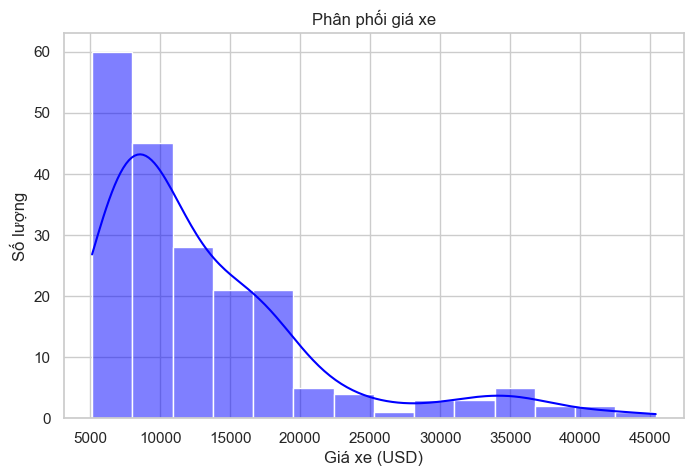

In [120]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], kde=True, color='blue')
plt.title('Phân phối giá xe')
plt.xlabel('Giá xe (USD)')
plt.ylabel('Số lượng')
plt.show()

**Nhận xét:** Phân phối giá xe có đuôi phải dài, nghĩa là đa số các mẫu xe có giá thấp, chỉ một số ít xe là có giá cao vượt trội.

## M2.2 Dataset có cân bằng theo body style không?

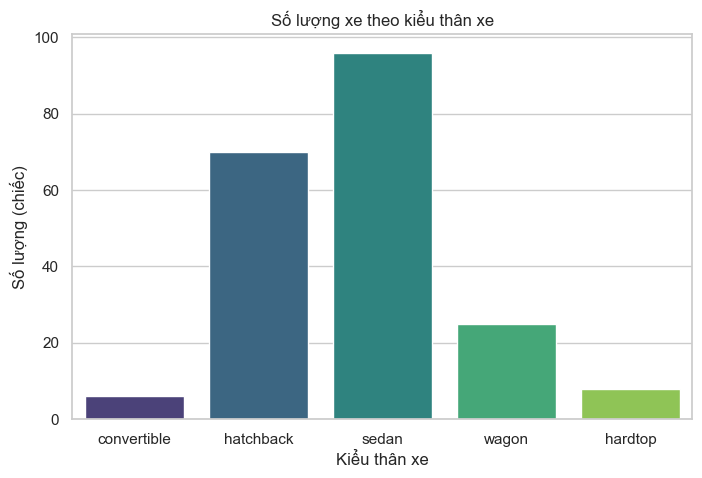

In [121]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean, 
    x='body_style', 
    hue='body_style',    
    palette='viridis', 
    legend=False         
)
plt.title('Số lượng xe theo kiểu thân xe')
plt.xlabel('Kiểu thân xe')
plt.ylabel('Số lượng (chiếc)')
plt.show()

**Nhận xét:** Dữ liệu không cân bằng; số lượng xe loại 'sedan' thường chiếm ưu thế áp đảo so với các loại khác như 'convertible' hay 'hardtop', điều này có thể gây ảnh hưởng cho các phân tích sau này.

## M2.3 Price khác nhau theo body style ra sao?

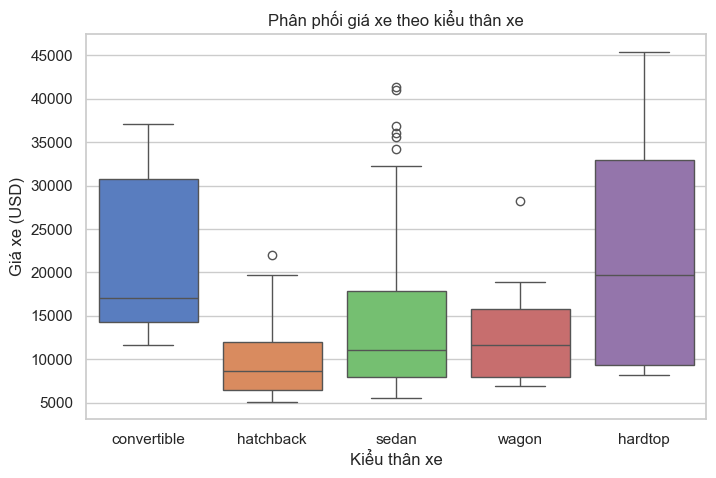

In [122]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean, 
    x='body_style', 
    y='price', 
    hue='body_style',  
    palette='muted', 
    legend=False         
)
plt.title('Phân phối giá xe theo kiểu thân xe')
plt.xlabel('Kiểu thân xe')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** Có sự khác biệt rõ rệt về giá giữa các kiểu thân xe; trong đó xe kiểu convertible và hardtop có phân khúc giá cao hơn hẳn. Ngoài ra, biểu đồ cho thấy sự xuất hiện của nhiều điểm ngoại lai (outliers) ở nhóm sedan, cho thấy sự phân hóa giá rất lớn trong dòng xe này.

## M2.4 Engine size liên quan thế nào tới price?

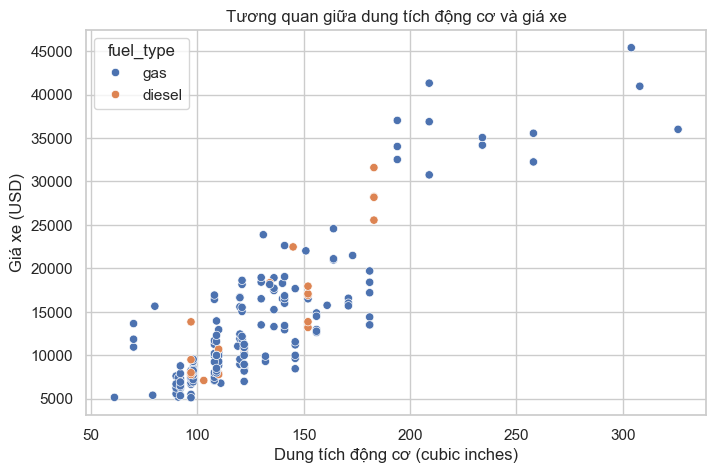

In [123]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type')
plt.title('Tương quan giữa dung tích động cơ và giá xe')
plt.xlabel('Dung tích động cơ (cubic inches)')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** Có tương quan thuận mạnh mẽ giữa dung tích động cơ và giá xe; động cơ càng lớn thì giá thường càng cao. Ngoài ra, việc sử dụng hue='fuel_type' giúp nhận thấy rõ hơn sự phân bổ giữa xe chạy xăng (gas) và diesel.

## M2.5 Các feature numeric tương quan ra sao?

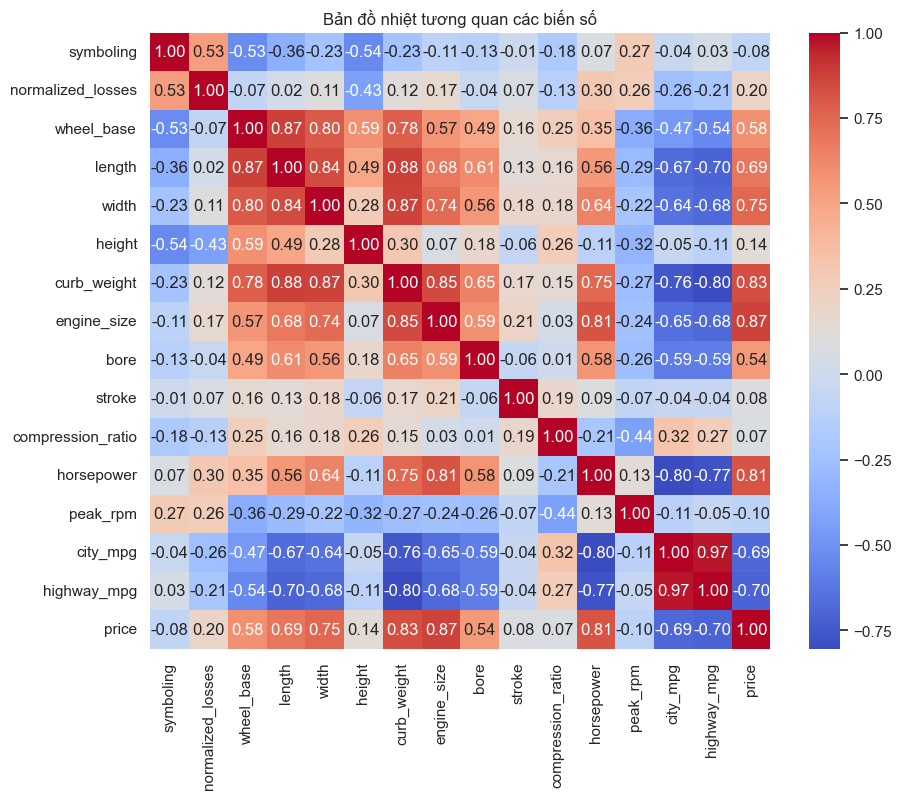

In [124]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Bản đồ nhiệt tương quan các biến số')
plt.show()

**Nhận xét:** Các biến như engine_size, curb_weight ..có tương quan thuận rất cao với price, cho thấy đây là những yếu tố chính quyết định giá xe. Ngược lại, city_mpg và highway_mpg thường có tương quan nghịch với giá, nghĩa là xe càng tiết kiệm nhiên liệu thì giá lại càng thấp hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

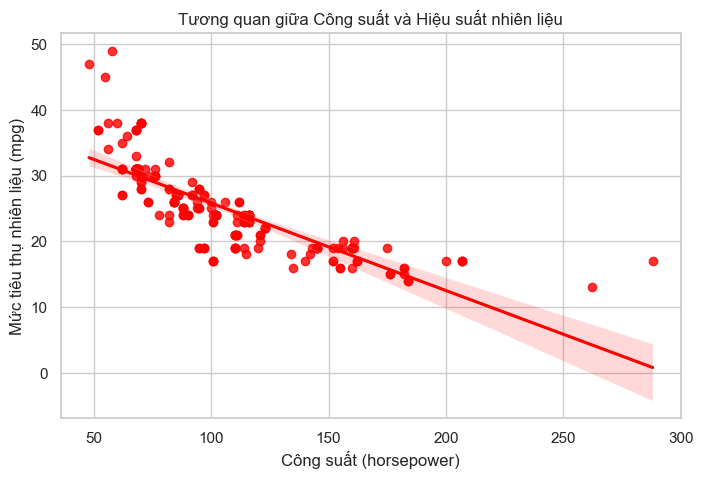

In [125]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(8, 5))
sns.regplot(data=df_clean, x='horsepower', y='city_mpg', color='red')

plt.title('Tương quan giữa Công suất và Hiệu suất nhiên liệu')
plt.xlabel('Công suất (horsepower)')
plt.ylabel('Mức tiêu thụ nhiên liệu (mpg)')
plt.show()

**Nhận xét:** Biểu đồ cho thấy xu hướng nghịch biến rõ rệt: những chiếc xe có công suất (horsepower) càng cao thì khả năng tiết kiệm nhiên liệu (mpg) càng giảm.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Qua quá trình phân tích bộ dữ liệu xe hơi 1985, em rút ra một số phát hiện chính sau:
Thứ nhất, có mối tương quan thuận rất mạnh giữa dung tích động cơ, công suất và giá xe, cho thấy đây là những yếu tố quyết định giá trị cốt lõi. Thứ hai, xe càng có công suất cao thì hiệu suất nhiên liệu (mpg) càng giảm, phản ánh sự đánh đổi trong kỹ thuật ô tô. Thứ ba, phân khúc xe convertible thường có giá cao hơn đáng kể so với mặt bằng chung.

Tuy nhiên, dataset vẫn tồn tại hạn chế: số lượng mẫu trong một vài phân khúc như convertible hay hardtop còn quá ít, dễ gây sai lệch; đồng thời, nhiều dữ liệu bị thiếu ở các cột quan trọng như normalized_losses làm giảm độ tin cậy của mô hình dự báo.

Cần lưu ý rằng correlation không đồng nghĩa với causation. Ví dụ, ta thấy công suất lớn tương quan với giá cao, nhưng không phải cứ lắp động cơ lớn vào xe là giá xe sẽ tăng tương ứng, vì giá còn chịu ảnh hưởng bởi thương hiệu và chất liệu.

Cuối cùng, tôi đề xuất câu hỏi nên phân tích tiếp: "Liệu sự thay đổi của giá nhiên liệu theo thời gian có làm thay đổi xu hướng ưu tiên của người dùng đối với các dòng xe có dung tích động cơ nhỏ hay không?"